### The resource for this lecture
https://nbviewer.org/urls/qutip.org/qutip-tutorials/tutorials-v5/lectures/Lecture-1-Jaynes-Cumming-model.ipynb

In [1]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
from qutip import (about, basis, destroy, mesolve, ptrace, qeye,
                   tensor, wigner, anim_wigner)
# set a parameter to see animations in line
from matplotlib import rc
rc('animation', html='jshtml')

%matplotlib inline

### The Jaynes-Cummings Model

The Jaynes-Cummings model represents the fundamental paradigm for quantum mechanical light-matter interaction. It describes a single two-level atom coupled to a single quantized mode of an electromagnetic cavity. 

In the dipole interaction form, the total system Hamiltonian is expressed as:

$$ H = \hbar \omega_c a^\dagger a + \frac{1}{2} \hbar \omega_a \sigma_z + \hbar g \left( a^\dagger + a \right) \left( \sigma_- + \sigma_+ \right) $$

#### The Rotating-Wave Approximation (RWA)
By applying the rotating-wave approximation, rapidly oscillating counter-rotating terms ($a^\dagger \sigma_+$ and $a \sigma_-$) are neglected. This simplification is highly accurate in the near-resonant regime ($\omega_c \approx \omega_a$) where the coupling strength is weak ($g \ll \omega_c, \omega_a$). The effective Hamiltonian reduces to:

$$ H_{\text{RWA}} = \hbar \omega_c a^\dagger a + \frac{1}{2} \hbar \omega_a \sigma_z + \hbar g \left( a^\dagger \sigma_- + a \sigma_+ \right) $$

where:
* $\omega_c$ and $\omega_a$ denote the angular frequencies of the cavity mode and atomic transition, respectively.
* $g$ represents the light-matter coupling strength.
* $a^\dagger$ ($a$) are the bosonic creation (annihilation) operators for the cavity field.
* $\sigma_z$, $\sigma_+$, and $\sigma_-$ are the standard Pauli and ladder operators for the two-level atom.

We also use units where $\hbar = 1$:

In [3]:
wc = 2 * np.pi # Cavity frequency
wa = 2 * np.pi # atom frequency
g = 0.05 * 2 * np.pi # Coupling strength
kappa = 0.005 # Cavity Dissipation rate
gamma = 0.05 # atom dissipation rate
N = 15 # The number of cavity fock states is a quantum state that is an element of a Fock space 
       #with a well-defined number of particles (or quanta).
n_th_a = 0.0 # avg '#' of thermal bath excitation
use_rwa = True # rotating-wave approximation

tlist = np.linspace(0, 25, 101)

### Setup the operators, the Hamiltonian and initial state

In [4]:
# inital state
psi0 = tensor(basis(N, 0), basis(2, 1)) # start with an excited atom basis(2, 1)

#operators
a = tensor(destroy(N), qeye(2))
sm = tensor(qeye(N), destroy(2))

#Hamiltonaian
if use_rwa:
    H = wc * a.dag() * a + wa * sm.dag() * sm +\
    g * (a.dag() * sm + a * sm.dag())

else:
    H = wc * a.dag() * a + wa * sm.dag() * sm + \
        g * (a.dag() + a) * (sm + sm.dag())

### Create a list of collapse operators that describe the dissipation

In [7]:
c_ops = []

# cavity relaxation
rate = kappa * (1+ n_th_a)
if rate > 0.0:
    c_ops.append(np.sqrt(rate)* a)

# cavity excitation, if temperature > 0
rate = kappa * n_th_a
if rate > 0.0:
    c_ops.append(np.sqrt(rate) * a.dag())

# qubit relaxation
rate = gamma
if rate > 0.0:
    c_ops.append(np.sqrt(rate) * sm)

### Evolve the system
Here we evolve the system with the Lindblad master equation solver, and we request that the expectation values of the operators  $a^\dagger a$ and  $\sigma_ + \sigma_ -$ are returned by the solver by passing the list [a()*a, sm.dag()*sm] as the fifth argument to the solver.

In [9]:
output = mesolve(H, psi0, tlist, c_ops, e_ops=[a.dag() * a, sm.dag() *sm])
output

<Result
  Solver: mesolve
  Solver stats:
    method: 'scipy zvode adams'
    init time: 4.887580871582031e-05
    preparation time: 0.00017714500427246094
    run time: 0.008580207824707031
    solver: 'Master Equation Evolution'
    num_collapse: 2
  Time interval: [0.0, 25.0] (101 steps)
  Number of e_ops: 2
  State not saved.
>

### Visualize the results
Here we plot the excitation probabilities of the cavity and the atom (these expectation values were calculated by the mesolve above). We can clearly see how energy is being coherently transferred back and forth between the cavity and the atom.

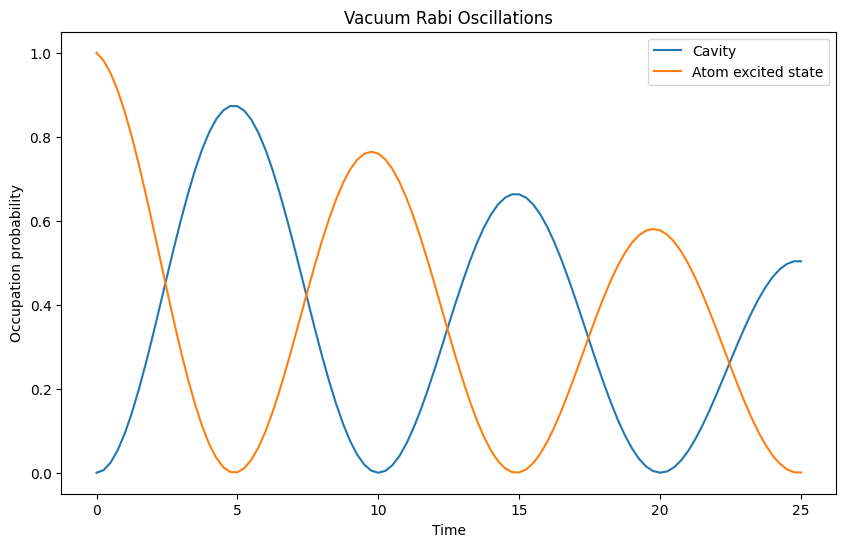

In [13]:
n_c = output.expect[0]
n_a = output.expect[1]

fig, axes = plt.subplots(1, 1, figsize = (10, 6))

axes.plot(tlist, n_c, label = "Cavity")
axes.plot(tlist, n_a, label = "Atom excited state")
axes.legend(loc=0)
axes.set_xlabel("Time")
axes.set_ylabel("Occupation probability")
axes.set_title("Vacuum Rabi Oscillations");